## Instructions {-}

1. You may talk to a friend, discuss the questions and potential directions for solving them. However, you need to write your own solutions and code separately, and not as a group activity. 

2. Write your code in the **Code cells** and your answers in the **Markdown cells** of the Jupyter notebook. Ensure that the solution is written neatly enough to for the graders to understand and follow.

3. Use [Quarto](https://quarto.org/docs/output-formats/html-basics.html) to render the **.ipynb** file as HTML. You will need to open the command prompt, navigate to the directory containing the file, and use the command: `quarto render filename.ipynb --to html`. Submit the HTML file.

4. The assignment is worth 100 points, and is due on **18th October 2025 at 11:59 pm**. 

5. **Five points are properly formatting the assignment**. The breakdown is as follows:
    - Must be an HTML file rendered using Quarto **(1 point)**. *If you have a Quarto issue, you must mention the issue & quote the error you get when rendering using Quarto in the comments section of Canvas, and submit the ipynb file.* 
    - No name can be written on the assignment, nor can there be any indicator of the student’s identity—e.g. printouts of the working directory should not be included in the final submission.  **(1 point)**
    - There aren’t excessively long outputs of extraneous information (e.g. no printouts of entire data frames without good reason, there aren’t long printouts of which iteration a loop is on, there aren’t long sections of commented-out code, etc.) **(1 point)**
    - Final answers to each question are written in the Markdown cells. **(1 point)**
    - There is no piece of unnecessary / redundant code, and no unnecessary / redundant text. **(1 point)**

6.  The maximum possible score in the assigment is 100  + 15 (bonus task) + 5 (AI usage disclosure)= 120 out of 100.

## Objective

- **Reinforce Knowledge of Gradient Descent:** Apply your understanding of gradient descent to classification problems by implementing logistic regression and softmax regression from scratch.
- **Hands-on Implementation:** Build classification models manually to gain deeper insights into their mathematical foundations and working principles.
- **Explore Customization Options:** Learn how implementing models from scratch allows you to:
  - Adjust and optimize model parameters for specific requirements.
  - Add features or constraints that might not be possible with standard libraries.
- **Compare with Pre-built Models:** Use scikit-learn’s logistic regression as a baseline to evaluate the performance and efficiency of your custom implementation. This will help you understand when to use custom models and when to leverage pre-built ones.
- **Prepare for Real-world Scenarios:** Understand the scenarios where off-the-shelf models are not sufficient, allowing you to confidently tackle complex machine learning problems and create novel solutions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, math

## Refreshing the Foundations: Sigmoid & Logistic Regression

### Why Logistic Regression? The Classification Challenge

<p align="center">
  <img src="images/image-96.webp" alt="Logistic Cost Function" width="400">
</p>

**The Problem**: Linear regression gives us $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$, but for classification:

- **Linear regression outputs**: Any real number (-∞ to +∞)
- **Classification needs**: Probabilities between 0 and 1
- **Binary targets**: $y \in \{0, 1\}$ (e.g., Disease/No Disease, Spam/Not Spam)

**The Solution**: Transform linear outputs into probabilities using the **sigmoid function**, creating a model that outputs meaningful probabilities for binary classification decisions.

**Real-World Context**: In this assignment, you'll predict heart disease risk where:
- **Input**: Patient medical data (age, cholesterol, chest pain type, etc.)
- **Output**: Probability of heart disease (0 = healthy, 1 = disease)
- **Goal**: Build a model doctors can trust for medical decision-making


### The Sigmoid Function: Mathematical Bridge to Probabilities

**Mathematical Definition:**
$$g(z) = \frac{1}{1 + e^{-z}} \tag{1}$$

**What This Function Does:**
- **Input $z$**: Any real number (-∞ to +∞) from linear model
- **Output $g(z)$**: Always between 0 and 1 (perfect for probabilities!)
- **S-shaped curve**: Smooth transition from 0 to 1

**Key Properties:**
- **$g(0) = 0.5$**: Neutral prediction (equal probability of both classes)
- **$g(z) \to 1$** as $z \to +\infty$: Strong positive evidence → high probability  
- **$g(z) \to 0$** as $z \to -\infty$: Strong negative evidence → low probability
- **Always smooth**: No sudden jumps, making it perfect for gradient descent optimization

**Practical Interpretation:**
In logistic regression, $z = \mathbf{w} \cdot \mathbf{x} + b$ represents the "log-odds" or "logit":
- **Positive $z$**: Model leans toward class 1 (e.g., "has disease")
- **Negative $z$**: Model leans toward class 0 (e.g., "healthy")  
- **Magnitude of $|z|$**: Confidence level of the prediction

**Implementation Note**: NumPy's [`exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) function handles vectorized computation efficiently, but requires careful numerical handling to avoid overflow (which you'll implement!).

### Logistic Regression: Model
<img align="left" src="./images/C1_W3_LogisticRegression_right.png"     style=" width:300px; padding: 10px; " > A logistic regression model applies the sigmoid to the familiar linear regression model as shown below:

$$ 
f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b ) \tag{2} 
$$ 

  where

  $$
  g(z) = \frac{1}{1+e^{-z}}\tag{3}
  $$

### Logistic Regression: Loss Function

Logistic Regression uses a loss function more suited to the task of categorization where the target is 0 or 1 rather than any number. 

>**Definition Note:**   In this course, these definitions are used:  
**Loss** is a measure of the difference of a single example to its target value while the  
**Cost** is a measure of the losses over the training set


This is defined: 
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is:

\begin{equation}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
    - \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=1$}\\
    - \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=0$}
  \end{cases}
\end{equation}


*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value.

*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot\mathbf{x}^{(i)}+b)$ where function $g$ is the sigmoid function.

The defining feature of this loss function is the fact that it uses two separate curves. One for the case when the target is zero or ($y=0$) and another for when the target is one ($y=1$). Combined, these curves provide the behavior useful for a loss function, namely, being zero when the prediction matches the target and rapidly increasing in value as the prediction differs from the target. Consider the curves below:

<div style="text-align: center;">
    <img src=https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTIyEcDUIGx9kLDohkOyjq8X2OkQZbxLoVW3JyEefVtog&s alt="Description of image" width="400"/>
</div>

Combined, the curves are similar to the quadratic curve of the squared error loss. Note, the x-axis is $f_{\mathbf{w},b}$ which is the output of a sigmoid. The sigmoid output is strictly between 0 and 1.

The loss function above can be rewritten to be easier to implement.
    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)$$
  
This is a rather formidable-looking equation. It is less daunting when you consider $y^{(i)}$ can have only two values, 0 and 1. One can then consider the equation in two pieces:  
when $ y^{(i)} = 0$, the left-hand term is eliminated:
$$
\begin{align}
loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), 0) &= (-(0) \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - 0\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \\
&= -\log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
\end{align}
$$
and when $ y^{(i)} = 1$, the right-hand term is eliminated:
$$
\begin{align}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), 1) &=  (-(1) \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - 1\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\\
  &=  -\log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
\end{align}
$$

**Why This Loss Function Works:**
1. **Probabilistic Foundation**: Derived from maximum likelihood estimation
2. **Convex Optimization**: Guarantees unique global minimum (perfect for gradient descent)
3. **Penalizes Confidence**: Wrong confident predictions get heavily penalized
4. **Smooth Gradients**: Enables stable gradient descent convergence

**Connection to Your Implementation**: This loss function is exactly what you'll implement in Task 1, with the addition of L2 regularization to prevent overfitting on the heart disease dataset.

### Logistic Regression: Cost Function (Training Objective)

**From Individual Loss to Overall Cost:**

The **cost function** aggregates individual losses across all training examples to create our optimization objective:

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

Where the individual **loss** for each example is:

$$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$

**The Complete Model Pipeline:**
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$

**Optimization Goal**: Find weights $\mathbf{w}$ and bias $b$ that minimize $J(\mathbf{w},b)$ using **gradient descent**.


## Bridge to Implementation: What You'll Build

### Your Assignment Journey:
1. **Task 1**: Implement cost function with L2 regularization → **20 points**  
2. **Task 2**: Apply to heart disease dataset with preprocessing → **15 points**  
3. **Task 3**: Experiment with regularization strength (λ) → **20 points**  
4. **Task 4**: Benchmark against scikit-learn LogisticRegression → **20 points**  
5. **Task 5**: Explore the `tol` parameter in gradient descent–based models → **15 points**  
6. **Task 6**: Summarize key learnings and insights → **5 points** 

### ⭐ Bonus Task  
Extend your L2-regularized logistic regression by adding a **`tol` stopping criterion**, and compare its behavior with scikit-learn’s implementation -> **15 points**
   
### Key Implementation Challenges You'll Solve:

- **Numerical Stability**: Prevent `log(0)` errors that break gradient descent
- **Vectorization**: Implement efficient matrix operations for real-world performance
- **Regularization**: Add L2 penalty to prevent overfitting on complex medical data
- **Gradient Computation**: Derive and implement the gradient for weight updates
- **Convergence Monitoring**: Track training progress and detect overfitting

### Real-World Impact:
Your implementation will predict heart disease risk using patient data—a model that could potentially assist medical professionals in making life-saving decisions. The mathematical rigor you develop here translates directly to production ML systems used in healthcare, finance, and technology.
 

## Task 1: Implementing L2 Regularized Logistic Regression with Vectorized Gradient Descent **(20 points)**

###  **Objective**
Implement a complete L2 regularized (Ridge) logistic regression algorithm from scratch using vectorized operations to prevent overfitting in binary classification problems.

### 📋 **Implementation Requirements**

#### **Main Function Signature**
Your implementation should create a main training function that takes these inputs:

- **X_train** (ndarray): Training feature matrix (m × n) - **Note**: Should include bias column of ones as first column
- **y_train** (ndarray): Training labels (m × 1) 
- **X_test** (ndarray): Test feature matrix for monitoring overfitting - **Note**: Should include bias column  
- **y_test** (ndarray): Test labels for performance tracking
- **w_in** (ndarray): Initial weights ((n+1) × 1) - **Includes bias weight as first element**
- **alpha** (float): Learning rate (typically 0.001 - 0.01)
- **num_iters** (int): Number of training iterations
- **lambda_reg** (float): L2 regularization strength (λ ≥ 0)

#### **Expected Outputs**
- **Optimized parameters**: Final weights after training
- **Training cost history**: Cost values at each iteration on training data
- **Test cost history**: Cost values at each iteration on test data (for overfitting analysis)

### **Implementation Structure**

#### **Step 1: Cost Function with L2 Regularization**
```python
def compute_cost_logistic_ridge(X, y, w, lambda_reg):
```
**Mathematical Formula:**
$$J(w) = \frac{1}{m}\sum_{i=1}^{m} \left[ -y^{(i)} \log(h_w(x^{(i)})) - (1-y^{(i)}) \log(1-h_w(x^{(i)})) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

Where $h_w(x) = \sigma(w^T x)$ and $\sigma(z) = \frac{1}{1+e^{-z}}$

**Key Implementation Notes:**

- Use vectorized operations for efficiency
- **Bias handling**: Don't regularize the bias term (w[0]) - exclude from L2 penalty
- **Data preparation**: Add column of ones to X matrices for bias term
- Handle numerical stability with log functions

**Why Numerical Stability Matters:**

- **When h = 0**: `log(0) = -∞` → **NaN in cost calculations**
- **When h = 1**: `log(1-h) = log(0) = -∞` → **NaN in cost calculations**  
- **When it occurs**: Sigmoid outputs extreme values (overconfident predictions)
- **Consequence**: Entire gradient descent breaks due to NaN propagation

   **Practical Example:**
   ```python
   # Without clipping - BREAKS!
   h = np.array([0.0, 0.5, 1.0])  # Sigmoid predictions
   cost = -np.log(h)  # Returns: [inf, 0.693, 0.0]
   # ↑ inf values propagate to gradients → NaN → training failure

   # With clipping - WORKS!
   h_safe = np.clip(h, 1e-15, 1-1e-15)  # Safe range: [1e-15, 1-1e-15]
   cost = -np.log(h_safe)  # Returns: [34.54, 0.693, 34.54]  
   # ↑ All finite values → stable gradients → successful training
   ```

**Professional Tip**: All major ML libraries (TensorFlow, PyTorch, sklearn) use similar clipping internally!

#### **Step 2: Gradient Computation with L2 Regularization**
```python
def compute_gradient_logistic_ridge(X, y, w, lambda_reg):
```
**Mathematical Formula:**
$$\frac{\partial J}{\partial w_j} = \frac{1}{m} X^T (\sigma(Xw) - y) + \frac{\lambda}{m} w_j \quad \text{(for } j > 0\text{)}$$
$$\frac{\partial J}{\partial w_0} = \frac{1}{m} X^T (\sigma(Xw) - y) \quad \text{(bias term, no regularization)}$$

**Implementation Note**: The gradient vector should be same shape as w_in ((n+1) × 1), where the first element corresponds to the bias term gradient (no regularization) and remaining elements include the L2 regularization term.

#### **Step 3: Gradient Descent Algorithm**
```python
def gradient_descent_logistic_ridge(X_train, y_train, X_test, y_test, w_in, alpha, num_iters, lambda_reg):
```

#### 💡 **Implementation Tips**

1. **Bias Term Setup**: 
   - Add column of ones as **first column** of X matrices: `X = np.column_stack([np.ones(m), X_features])`
   - Initialize w_in with shape (n+1, 1) where w[0] is bias, w[1:] are feature weights
2. **Vectorization**: Use matrix operations instead of loops for efficiency
3. **Numerical Stability**: 
   - Clip extreme values in sigmoid to prevent overflow
   - Use `np.clip(predictions, 1e-15, 1-1e-15)` for log calculations
4. **Regularization Implementation**: 
   - Create regularization vector: `reg_term = np.copy(w); reg_term[0] = 0` (exclude bias)
   - Add to gradient: `gradient + (lambda_reg/m) * reg_term`
5. **Monitoring**: Track both training and test costs to observe overfitting


#### ✅ **Validation Checklist**
- [ ] Cost decreases monotonically during training
- [ ] Implementation uses vectorized operations (no explicit loops over samples)
- [ ] Regularization term correctly excludes bias
- [ ] Both training and test costs are tracked
- [ ] Function handles edge cases (very small/large predictions)


In [4]:
## Step 1
def compute_cost_logistic_ridge(X, y, w, lambda_reg):
    m = X.shape[0]

    z = X @ w
    h = 1 / (1 + (np.exp(-1 * z)))

    term1 = (-1 * y) * np.log(np.clip(h, 1e-15, 1-1e-15))
    term2 = (1 - y) * np.log(1 - np.clip(h, 1e-15, 1-1e-15))
    summation = np.sum(term1 - term2)
    unreg_cost = summation / m

    reg = np.dot(w[1:].T, w[1:])
    reg = reg * (lambda_reg / (2*m))

    cost = unreg_cost + reg
    return cost


## Step 2
def compute_gradient_logistic_ridge(X, y, w, lambda_reg):
    m = X.shape[0]
    w_copy = copy.deepcopy(w)
    w_copy[0] = 0

    z = X @ w
    h = 1 / (1 + (np.exp(-1 * z)))
    error = h - y
    product = np.dot(X.T, error)
    dj_dw = (product / m) + (lambda_reg / m) * w_copy
    return dj_dw


## Step 3
def gradient_descent_logistic_ridge(X_train, y_train, X_test, y_test, w_in, alpha, num_iters, lambda_reg, print_iterations=True):
    m_train = X_train.shape[0]
    X_train_bias = np.column_stack((np.ones((m_train, 1)), X_train))
    w = copy.deepcopy(w_in)
    w_bias = np.concatenate((np.array([0]), w))
    m_test = X_test.shape[0]
    X_test_bias = np.column_stack((np.ones((m_test, 1)), X_test))

    J_history, J_test_history = [], []

    for i in range(num_iters):
        dj_dw = compute_gradient_logistic_ridge(X_train_bias, y_train, w_bias, lambda_reg)
        w_bias = w_bias - alpha * dj_dw
        train_cost = compute_cost_logistic_ridge(X_train_bias, y_train, w_bias, lambda_reg)
        test_cost = compute_cost_logistic_ridge(X_test_bias, y_test, w_bias, lambda_reg)
        J_history.append(train_cost)
        J_test_history.append(test_cost)
        if print_iterations:
            if i % 1000 == 0:
                print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
    
    return w_bias, J_history, J_test_history
        


## Task 2: Apply your implementation on a real dataset **(15 points)**

### **Objective**
Apply your L2 regularized logistic regression implementation to predict heart disease using a real medical dataset, demonstrating proper data preprocessing, model training, and performance visualization.

### **Dataset Overview** 
The **heart_disease_classification.csv** contains medical data for heart disease prediction with:

- **Target**: Binary classification (0=No Disease, 1=Disease)  
- **Features**: Mix of numerical (age, cholesterol) and categorical (chest pain type, slope)
- **Challenge**: Categorical variables need proper encoding for your algorithm

### 📋 **Step-by-Step Implementation Guide**

#### **Step 1: Data Loading and Initial Exploration**

In this step, you will begin by **importing the dataset into your working environment** (e.g., using `pandas.read_csv()` for CSV files). After successfully loading the data, perform some **basic exploratory checks** to understand its structure and contents. This includes:

- Displaying the **first few rows** of the dataset with `.head()` to get a sense of the data format  
- Checking the **dimensions** of the dataset with `.shape` to see how many rows and columns are available  
- Inspecting the **column names and data types** with `.info()` to identify numerical, categorical, and datetime features  
- Reviewing **summary statistics** with `.describe()` to quickly understand ranges, averages, and distributions of numeric columns  

This step ensures that you have properly loaded the dataset and gained a **high-level understanding of its characteristics**, which is essential before moving into deeper transformation, or modeling tasks.

In [5]:
df = pd.read_csv('heart_disease_classification.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\n')
df.info()

Rows: 303
Columns: 14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


#### **Step 2: Data Shuffling and Feature-Target Separation (*random_state=0*)**

After loading and exploring the dataset, the next step is to **prepare it for modeling**. This involves two tasks:

1. **Shuffling the data**
   - Many real-world datasets, especially in domains like **medicine**, are collected in sequential order (e.g., sorted by collection date, patient ID, or clinical visit number).  
   - If you split the dataset without shuffling, the training set may contain only earlier cases and the test set may contain only later ones. This can introduce **temporal or ID-based bias** and reduce the model’s ability to generalize.  
   - Shuffling ensures that the **distribution of samples is random**, giving both training and test sets a representative mix of patients and outcomes.  
   - We use `random_state=0` to make the shuffle **reproducible**, so everyone gets the same randomized order.  

2. **Separating features and target**
   - Define the **target variable** (the outcome you want to predict, e.g., disease status, biomarker level, or treatment response).  
   - Select the **features** (independent variables, such as patient demographics, lab values, or imaging-derived metrics).  
   - Split the dataset into:  
     - `X` → the **feature matrix** (all input variables except the target)  
     - `y` → the **target vector** (the label or response variable)  

In [8]:
df_shuffled = df.sample(frac=1, random_state=0).reset_index(drop=True)
X = df_shuffled.drop(columns=['target'])
y = df_shuffled.target

#### **Step 3: Train–Test Split (random_state=42) and Feature Scaling**

Once the dataset is shuffled and the features (`X`) and target (`y`) are separated, the next step is to **divide the data into training and testing subsets**.  

- **Training set**: Used to fit the model (learn the patterns from the data).  
- **Test set**: Held back to evaluate how well the model generalizes to unseen data.  

We typically use **80% of the data for training** and **20% for testing**, though this ratio can be adjusted based on dataset size and problem context.  

To ensure reproducibility, we specify `random_state=42` when performing the split.  

##### ✅ Why split the data?

- Prevents **overfitting** by ensuring the model is evaluated on unseen data.  
- Mimics a real-world scenario where the model encounters new patient cases.  
- Provides an unbiased estimate of model performance. 

##### ✅ Why scaling matters
- Features may be measured on very different scales (e.g., **age** ranges 20–80, while **cholesterol** may range 100–600).  
- Algorithms that use **gradient descent** (e.g., logistic regression, neural networks) can converge slowly or get stuck if features are not scaled properly.  
- Scaling puts all features on a **comparable range**, improving both **training stability** and **model performance**. 

**Important Notes**:  

- Use `fit_transform()` **only on the training set** so the scaler does not "see" information from the test set (**avoiding data leakage**).  
- Apply the fitted scaler to the **test set** using `transform()`.


In [9]:
cat_columns=['cp', 'thal', 'slope']
num_columns = [col for col in X.columns if col not in cat_columns]

In [10]:
for col_name in cat_columns:
    col = X[col_name]
    X = X.drop(columns = [col_name])
    X[col_name] = col

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train_num = X_train[num_columns]
X_test_num = X_test[num_columns]

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)


#### **Step 4: Categorical Variable Encoding**

The dataset contains **categorical variables** that must be converted into numerical form before modeling. Most machine learning algorithms cannot directly handle categorical text values, so we use **binary (dummy) encoding**.


**Required Encoding for These Columns:**
- **`cp`** (Chest Pain Type): Convert into binary dummy variables  
- **`thal`** (Thalassemia): Convert into binary dummy variables  
- **`slope`** (ST Slope): Convert into binary dummy variables  


##### ✅ Why Encode?
- Machine learning algorithms work with **numbers**, not text labels.  
- Encoding categorical variables as dummy variables prevents the model from assuming an **ordinal relationship** between categories (e.g., category "3" is not “greater than” category "1").  
- This ensures that the algorithm treats categories as **independent groups**.  



##### Example (using `pandas.get_dummies`)

```python
import pandas as pd

# Encode categorical variables into dummy variables
df_encoded = pd.get_dummies(df, columns=['cp', 'thal', 'slope'], drop_first=True)

# View the new columns
df_encoded.head()
```
Here:

- `pd.get_dummies()` automatically creates binary (0/1) columns for each category.

- `drop_first=True` avoids multicollinearity by dropping one category from each variable as the reference group.


In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', drop='first')
X_train_cat = X_train[cat_columns]
X_test_cat = X_test[cat_columns]

X_train_cat_encoded = encoder.fit_transform(X_train_cat).toarray()
X_test_cat_encoded = encoder.transform(X_test_cat).toarray()

In [13]:
columns = list(scaler.get_feature_names_out()) + list(encoder.get_feature_names_out())
X_train_in = np.column_stack((X_train_num_scaled, X_train_cat_encoded))
X_test_in = np.column_stack((X_test_num_scaled, X_test_cat_encoded))

#### **Step 5: Model Training and Hyperparameter Selection**

With the training and test sets prepared, the next step is to **train the model**. This involves selecting appropriate **hyperparameters** that control how the algorithm learns.  


##### ✅ Key Considerations
- **Learning Rate (`α`)**: Controls the step size during gradient descent updates.  
  - Too large → the algorithm may diverge.  
  - Too small → convergence becomes very slow.  

- **Number of Iterations / Epochs**: Determines how many times the algorithm goes through the training data.  
  - Choose enough iterations for convergence, but avoid unnecessary computation.  

- **Regularization (if applicable)**: Prevents overfitting by penalizing large weights.  

#####  Practical Setup
- Initialize parameters (`w_in`).  
- Select a reasonable learning rate (`alpha`).  
- Choose the number of iterations (`num_iters`).  
- Set a regularization strength (`lambda_reg`).  

As long as the model **converges stably**, your hyperparameters are acceptable.  


In [14]:
w_in = np.zeros(X_train_in.shape[1])
alpha = 0.2
num_iters = 20000
lambda_reg = 0.2

gd_log_w, J_history, test_J_history = gradient_descent_logistic_ridge(X_train_in, y_train, X_test_in, y_test, w_in, alpha, num_iters, lambda_reg)


Iteration    0: Cost     0.63   
Iteration 1000: Cost     0.32   
Iteration 2000: Cost     0.32   
Iteration 3000: Cost     0.32   
Iteration 4000: Cost     0.32   
Iteration 5000: Cost     0.32   
Iteration 6000: Cost     0.32   
Iteration 7000: Cost     0.32   
Iteration 8000: Cost     0.32   
Iteration 9000: Cost     0.32   
Iteration 10000: Cost     0.32   
Iteration 11000: Cost     0.32   
Iteration 12000: Cost     0.32   
Iteration 13000: Cost     0.32   
Iteration 14000: Cost     0.32   
Iteration 15000: Cost     0.32   
Iteration 16000: Cost     0.32   
Iteration 17000: Cost     0.32   
Iteration 18000: Cost     0.32   
Iteration 19000: Cost     0.32   


#### **Step 6: Plot the Learning Curve of Gradient Descent**

After training the model with gradient descent, it is important to **visualize the learning process**. A learning curve shows how the model’s **loss or accuracy changes** over iterations (epochs) for both the **training set** and the **test set**.


##### ✅ Why Learning Curves Matter
- **Convergence Check**: Helps verify whether gradient descent is converging to a minimum.  
- **Underfitting vs. Overfitting**:  
  - If both training and test errors are high → underfitting.  
  - If training error is low but test error is high → overfitting.  
- **Hyperparameter Tuning**: Reveals whether changes in learning rate (`α`), number of iterations, or regularization improve training stability.  


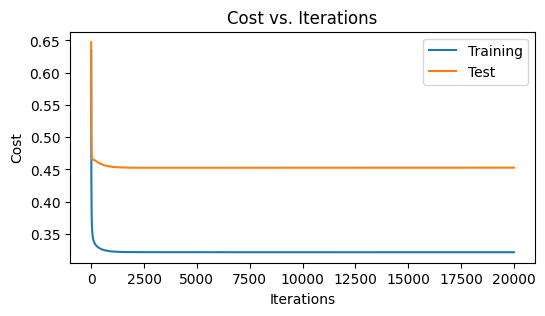

In [15]:
plt.figure(figsize=(6, 3))
plt.plot(J_history, label='Training')
plt.plot(test_J_history, label='Test')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations')
plt.legend()
plt.show()

## Task 3: Regularization Analysis - Finding the Optimal λ Value **(20 points)**

`lambda_reg` controls the strength of the regularization applied to the model.  
- When `lambda_reg` is set to **zero**, regularization is effectively turned off.  
- As `lambda_reg` increases, the penalty for large weights becomes more significant, helping to **reduce overfitting**.  



### 🔧 Task Instructions
- Experiment with different values of `lambda_reg` in the set **[0.0, 0.01, 0.03, 0.1, 0.3]**.  
- Plot the **learning curves** for both the training and test sets on the same figure to visualize the impact of each value.  
- Determine which value of `lambda_reg` yields the **best performance** on this dataset.  
- Report the performance (accuracy, precision, recall) using the best value of:  
  - **Accuracy**  
  - **Precision**  
  - **Recall**  



**Hyperparameters for this task**:  
- `learning_rate = 0.005`  
- `num_iterations = 1200`  


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

w_in = np.zeros(X_train_in.shape[1])
alpha = 0.005
num_iters = 1200

cost_histories = {}
lambda_values = [0.0, 0.01, 0.03, 0.1, 0.3]
for l in lambda_values:
    gd_log_w, J_history, test_J_history = gradient_descent_logistic_ridge(X_train_in, y_train, X_test_in, y_test, w_in, alpha, num_iters, l, print_iterations=False)
    cost_histories[l] = [J_history, test_J_history]

    m_test = X_test_in.shape[0]
    X_test_bias = np.column_stack((np.ones((m_test, 1)), X_test_in))
    z = X_test_bias @ gd_log_w
    h = 1 / (1 + (np.exp(-1 * z)))
    y_pred = (h >= 0.5).astype(int)

    print('Lambda value=', l)
    print('Accuracy=', accuracy_score(y_test, y_pred))
    print('Precision=', precision_score(y_test, y_pred))
    print('Recall=', recall_score(y_test, y_pred))

Lambda value= 0.0
Accuracy= 0.8032786885245902
Precision= 0.7948717948717948
Recall= 0.8857142857142857
Lambda value= 0.01
Accuracy= 0.8032786885245902
Precision= 0.7948717948717948
Recall= 0.8857142857142857
Lambda value= 0.03
Accuracy= 0.8032786885245902
Precision= 0.7948717948717948
Recall= 0.8857142857142857
Lambda value= 0.1
Accuracy= 0.8032786885245902
Precision= 0.7948717948717948
Recall= 0.8857142857142857
Lambda value= 0.3
Accuracy= 0.8032786885245902
Precision= 0.7948717948717948
Recall= 0.8857142857142857


All values of lambda in the set **[0.0, 0.01, 0.03, 0.1, 0.3]** have the same performance, as measured by accuracy, precision, and recall. The fact that the model performs just as well without regularization as it does when `lambda_reg = 0.3` suggests the possibility there is no overfitting to correct.

#### Learning Curves

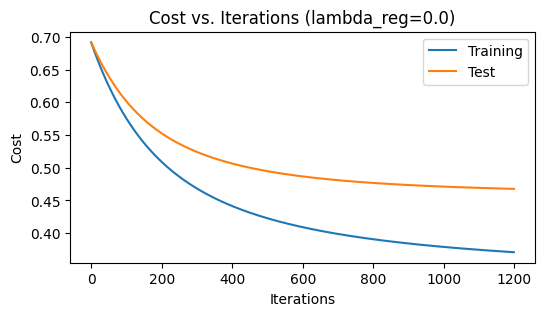

In [17]:
plt.figure(figsize=(6, 3))
plt.plot(cost_histories[0.0][0], label='Training')
plt.plot(cost_histories[0.0][1], label='Test')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (lambda_reg=0.0)')
plt.legend()
plt.show()

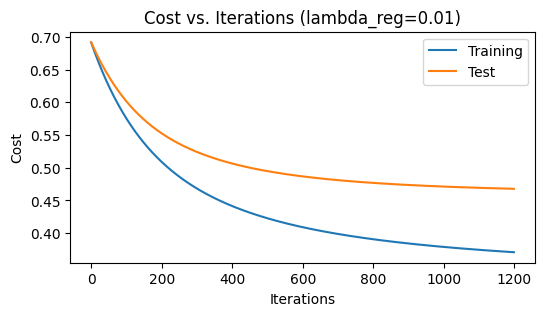

In [18]:
plt.figure(figsize=(6, 3))
plt.plot(cost_histories[0.01][0], label='Training')
plt.plot(cost_histories[0.01][1], label='Test')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (lambda_reg=0.01)')
plt.legend()
plt.show()

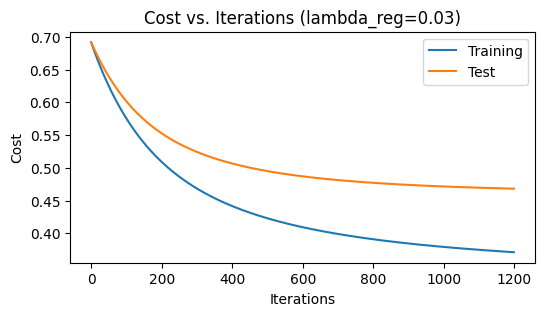

In [19]:
plt.figure(figsize=(6, 3))
plt.plot(cost_histories[0.03][0], label='Training')
plt.plot(cost_histories[0.03][1], label='Test')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (lambda_reg=0.03)')
plt.legend()
plt.show()

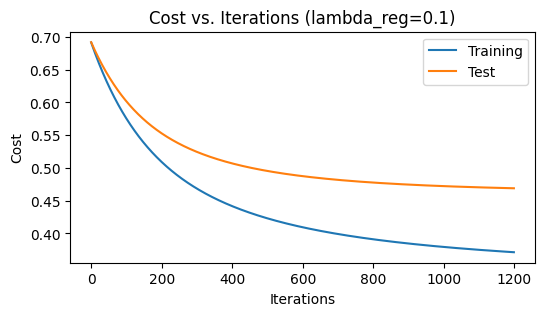

In [20]:
plt.figure(figsize=(6, 3))
plt.plot(cost_histories[0.1][0], label='Training')
plt.plot(cost_histories[0.1][1], label='Test')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (lambda_reg=0.1)')
plt.legend()
plt.show()

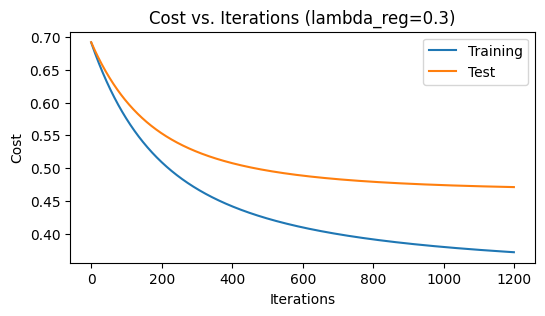

In [21]:
plt.figure(figsize=(6, 3))
plt.plot(cost_histories[0.3][0], label='Training')
plt.plot(cost_histories[0.3][1], label='Test')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (lambda_reg=0.3)')
plt.legend()
plt.show()

## Task 4: Custom vs. scikit-learn — Comprehensive Benchmark Analysis **(20 points)**

- Use the **`LogisticRegression`** model from **scikit-learn** to re-evaluate the dataset while keeping the same (or as similar as possible) hyperparameter settings for a **fair comparison**.  
- Report the performance using the **same evaluation metrics** as previously used.  
- Compare the results to your **custom implementation**. Analyze whether scikit-learn’s built-in logistic regression achieves similar, better, or worse performance.  
- Explain the potential reasons for any differences you observe. 



In [360]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(penalty='l2', C=33.3, max_iter=1200, fit_intercept=True)
log_model.fit(X_train_in, y_train)
y_pred = log_model.predict(X_test_in)

print("Scikit-learn's performance:")
print('Accuracy=', accuracy_score(y_test, y_pred))
print('Precision=', precision_score(y_test, y_pred))
print('Recall=', recall_score(y_test, y_pred))
print('\n')
print("Performance of custom implementation:")
print('Accuracy=', 0.8033)
print('Precision=', 0.7949)
print('Recall=', 0.8857)


Scikit-learn's performance:
Accuracy= 0.7868852459016393
Precision= 0.775
Recall= 0.8857142857142857


Performance of custom implementation:
Accuracy= 0.8033
Precision= 0.7949
Recall= 0.8857


Both scikit-learn's built-in logistic regression function and my custom implementation of L2 regularization achieved the same recall. However, for accuracy and precision, my custom implementation performed slightly better. 

One reason that may account for this discrepancy is the optimization methods used by the two models are different. While my custom implementation optimizes the model's parameters through regularized gradient descent, sklearn's model uses the `lbfgs` solver. Since these two optimization methods operate differently, the slightly better performance by my custom implementation may be attributed to the dataset's characteristics being more favorable to gradient descent in this particular instance. Another element that can potentially explain the difference is the presence of a learning rate in my implementation. Since the `lbfgs` solver doesn't use a learning rate in the same way as my implementation, this difference may have also influenced model performance.

## Task 5: Understanding Convergence - The `tol` Parameter Deep Dive **(15 points)**

In many models that use gradient descent–based optimization, `tol` is a key hyperparameter.  
In this task, you will explore its role using **logistic regression**.

### **Understanding the Tolerance Parameter**
The `tol` parameter in sklearn's LogisticRegression controls **when to stop the optimization process**:

- **What it measures**: Maximum change in the optimization objective between iterations
- **Stopping criterion**: Training stops when improvement falls below this threshold
- **Trade-off**: Tighter tolerance (smaller values) → more iterations → potentially better convergence
- **Efficiency**: Looser tolerance (larger values) → fewer iterations → faster training but potentially suboptimal results

### **Mathematical Context**
For solver convergence, sklearn typically uses:
$$|\nabla J(\mathbf{w}^{(t)}) - \nabla J(\mathbf{w}^{(t-1)})| < \text{tol}$$
Or for objective function change:
$$|J(\mathbf{w}^{(t)}) - J(\mathbf{w}^{(t-1)})| < \text{tol}$$


### **Expected Insights**

Experiment with the following `tol` values to explore their impact on model convergence, training speed, and performance:

**Typical Patterns You Should Observe:**
- **Tighter tolerance (`1e-6`, `1e-7`)** → Training is slower but may yield slightly better performance.  
- **Moderate tolerance (`1e-4`, `1e-5`)** → A good balance between speed and accuracy (close to scikit-learn’s default).  
- **Loose tolerance (`1e-1`, `1e-2`)** → Faster training but may stop too early, leading to suboptimal results.  
- **Performance plateau** → Beyond a certain level of tightness, further decreasing tolerance does not yield meaningful gains.  
- **Convergence issues** → Extremely tight tolerance may require more iterations than allowed, preventing proper convergence.  


### ✅ **Success Criteria**
- [ ] Systematic testing across tolerance range (8+ values)
- [ ] Comprehensive performance and efficiency metrics
- [ ] Professional visualization with multiple perspectives
- [ ] Clear identification of trade-offs and recommendations
- [ ] Evidence-based analysis of sklearn's default choice

To evaluate the impact of the `tol` parameter on model performance, convergence, and training speed, I tested 13 tolerance values ranging from `1e-1` to `1e-9`. In the code block below, I evaluated both performance and the number of iterations for each tolerance value. I noticed that all performance metrics (accuracy, precision, and recall) were identical for tol values less (tighter) than or equal to `1e-4`. Tol values greater (looser) than `1e-4` showed some variability in their performance. This suggests that performance may plateau after `1e-4`, which means that tighter values may be unnecessary. Another trade-off I observed was that as tol values increased, the number of iterations decreased (visualized in Figure 1). This is to be expected, as large tol values are more likely to be reached in earlier iterations.

In the `Convergence` section below, I tested whether a model would converge for different values of `max_iter`. I observed that convergence only occurred when `max_iter` was at least 40. **This was particularly interesting, as the `1e-4` tol value in my performance test caused its model to stop after 38 iterations.** This suggests that a tol value of `1e-4` may be near the threshold for convergence. 

Lastly, in the `Training Speed` section, I evaluated the training speed of models with different values `max_iter` (the same values were tested in the `Convergence` section). As expected, training time increased with iteration count (visualized in Figure 2). However, after 40 iterations, training time began to plateau. This reinforces the argument that using a tol value tighter than `1e-4` results in diminishing returns in terms of efficiency. 

My analysis of model performance, convergence, and training speed validates sklearn's default choice, `1e-4`. This value achieves a balanced trade-off between convergence, training time, and model performance; it is tight enough for the model to converge and for good performance, but loose enough to train efficiently.

### Performance

In [382]:
tolerances = [1e-1, 1e-2, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6, 5e-7, 1e-7, 1e-8, 1e-9]
results = {}
for t in tolerances:
    log_model = LogisticRegression(tol=t, penalty='l2', max_iter=1000, C=33.3, fit_intercept=True)
    log_model.fit(X_train_in, y_train)

    y_pred = log_model.predict(X_test_in)

    num_iters = log_model.n_iter_[0]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    metrics = {'num_iters':num_iters, 'accuracy':accuracy, 'precision':precision, 'recall':recall}
    results[t] = metrics

tol_performance_df = pd.DataFrame(results).T
tol_performance_df

,num_iters,accuracy,precision,recall
1.000000e-01,1.0,0.786885,0.789474,0.857143
1.000000e-02,6.0,0.786885,0.775000,0.885714
1.000000e-03,12.0,0.770492,0.769231,0.857143
5.000000e-04,13.0,0.770492,0.769231,0.857143
1.000000e-04,38.0,0.786885,0.775000,0.885714
5.000000e-05,39.0,0.786885,0.775000,0.885714
1.000000e-05,44.0,0.786885,0.775000,0.885714
5.000000e-06,45.0,0.786885,0.775000,0.885714
1.000000e-06,53.0,0.786885,0.775000,0.885714
5.000000e-07,55.0,0.786885,0.775000,0.885714


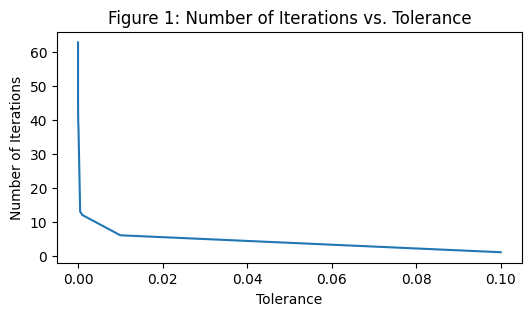

In [395]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(6, 3))
plt.plot(tol_performance_df.index, tol_performance_df['num_iters'], label=col)
plt.title("Figure 1: Number of Iterations vs. Tolerance")
plt.xlabel("Tolerance")
plt.ylabel("Number of Iterations")
plt.show()

### Convergence

In [384]:
import warnings
warnings.filterwarnings('default')
num_iters = [1,10,20,30,40,50,60]
warning_results = {}
for n in num_iters:
    warning = False
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        test_model = LogisticRegression(max_iter=n, penalty='l2', C=33.3, fit_intercept=True, random_state=0)
        test_model.fit(X_train_in, y_train)
        if len(w) > 0:
            warning=True
        warning_results[n] = warning

pd.Series(warning_results, name='Stopped Early')

1      True
10     True
20     True
30     True
40    False
50    False
60    False
Name: Stopped Early, dtype: bool

### Training Speed

In [385]:
import time
import warnings
warnings.filterwarnings('ignore')

num_iters = [1,10,20,30,40,50,60]
training_time_results = {}
for n in num_iters:
    training_times = []
    for i in range(1000):
        test_model = LogisticRegression(max_iter=n, penalty='l2', C=33.3, fit_intercept=True, random_state=0)
        start_time = time.perf_counter_ns()
        test_model.fit(X_train_in, y_train)
        end_time = time.perf_counter_ns()
        training_time = end_time - start_time
        training_times.append(training_time)
    avg_training_time = np.mean(training_times)
    training_time_results[n] = int(avg_training_time) / 1000000

pd.Series(training_time_results, name='Training Time (ms)')

1     0.434343
10    0.690186
20    1.003577
30    1.342629
40    1.647170
50    1.601432
60    1.612947
Name: Training Time (ms), dtype: float64

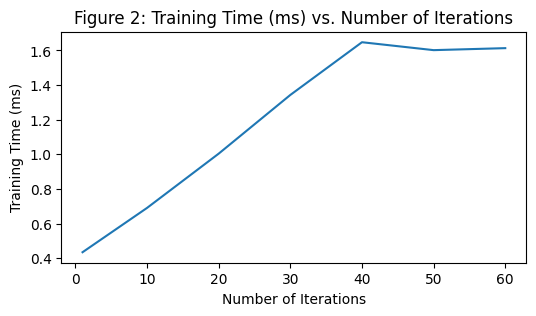

In [386]:
plt.figure(figsize=(6, 3))
plt.plot(list(training_time_results.keys()), list(training_time_results.values()))
plt.title("Figure 2: Training Time (ms) vs. Number of Iterations")
plt.xlabel("Number of Iterations")
plt.ylabel("Training Time (ms)")
plt.show()

## Bonus Task: Implementing `tol` in Your L2 Gradient Descent (15 points)

*This is a bonus task, feel free to skip this task*

To make your **custom L2-regularized gradient descent** implementation comparable with scikit-learn’s `LogisticRegression`, you should add the `tol` parameter as a **stopping criterion**.  

### ✅ Instructions:
1. During each iteration of gradient descent, compute the **change in cost (loss)** between the current and previous step.  
2. If the change is **smaller than `tol`**, stop the training loop early.  
3. Use the same tolerance values (`tol`) as in scikit-learn for a fair comparison.  
4. Report:  
   - The number of iterations completed before convergence.  
   - Final training and test performance metrics.  

In [391]:
## Implement L2 Gradient Descent with the tol parameter

def l2_logistic_gd_tol(X_train, y_train, X_test, y_test, w_in, alpha, num_iters, lambda_reg, tol, print_iterations=True):
    m_train = X_train.shape[0]
    X_train_bias = np.column_stack((np.ones((m_train, 1)), X_train))
    w = copy.deepcopy(w_in)
    w_bias = np.concatenate((np.array([0]), w))
    m_test = X_test.shape[0]
    X_test_bias = np.column_stack((np.ones((m_test, 1)), X_test))

    J_history, J_test_history = [], []
    num_iterations = num_iters

    for i in range(num_iters):
        dj_dw = compute_gradient_logistic_ridge(X_train_bias, y_train, w_bias, lambda_reg)
        w_bias = w_bias - alpha * dj_dw
        train_cost = compute_cost_logistic_ridge(X_train_bias, y_train, w_bias, lambda_reg)
        if J_history:
            prev_cost = J_history[-1]
            if np.abs(train_cost - prev_cost) < tol:
                num_iterations = i
                break
        test_cost = compute_cost_logistic_ridge(X_test_bias, y_test, w_bias, lambda_reg)
        J_history.append(train_cost)
        J_test_history.append(test_cost)
        if print_iterations:
            if i % 1000 == 0:
                print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
    
    return w_bias, J_history, J_test_history, num_iterations

In [393]:
w_in = np.zeros(X_train_in.shape[1])
alpha = 0.005
num_iters = 1200
lambda_reg = 0.03

gd_tolerances = [1e-1, 1e-2, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6, 5e-7, 1e-7, 1e-8, 1e-9]
gd_results = {}

for t in gd_tolerances:
    gd_tol_w, tol_J_history, tol_J_test_history, tol_num_iterations = l2_logistic_gd_tol(X_train_in, y_train, X_test_in, y_test, w_in, alpha, num_iters, lambda_reg, tol=t, print_iterations=False)

    # Train metrics
    m_train = X_train_in.shape[0]
    X_train_bias = np.column_stack((np.ones((m_train, 1)), X_train_in))

    z = X_train_bias @ gd_tol_w
    h = 1 / (1 + (np.exp(-1 * z)))
    y_train_pred = (h >= 0.5).astype(int)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)

    # Test metrics
    m_test = X_test_in.shape[0]
    X_test_bias = np.column_stack((np.ones((m_test, 1)), X_test_in))

    z = X_test_bias @ gd_tol_w
    h = 1 / (1 + (np.exp(-1 * z)))
    y_pred = (h >= 0.5).astype(int)

    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)

    metrics = {'num_iters':tol_num_iterations, 'Test accuracy':test_accuracy, 'Test precision':test_precision, 'Test recall':test_recall, 'Training accuracy':train_accuracy, "Training precision":train_precision, "Training recall":train_recall}
    gd_results[t] = metrics

gd_tol_performance_df = pd.DataFrame(gd_results).T
gd_tol_performance_df

,num_iters,Test accuracy,Test precision,Test recall,Training accuracy,Training precision,Training recall
1.000000e-01,1.0,0.786885,0.789474,0.857143,0.838843,0.822695,0.892308
1.000000e-02,1.0,0.786885,0.789474,0.857143,0.838843,0.822695,0.892308
1.000000e-03,74.0,0.803279,0.794872,0.885714,0.838843,0.822695,0.892308
5.000000e-04,204.0,0.803279,0.794872,0.885714,0.838843,0.827338,0.884615
1.000000e-04,662.0,0.819672,0.815789,0.885714,0.838843,0.827338,0.884615
5.000000e-05,979.0,0.803279,0.794872,0.885714,0.847107,0.834532,0.892308
1.000000e-05,1200.0,0.803279,0.794872,0.885714,0.847107,0.834532,0.892308
5.000000e-06,1200.0,0.803279,0.794872,0.885714,0.847107,0.834532,0.892308
1.000000e-06,1200.0,0.803279,0.794872,0.885714,0.847107,0.834532,0.892308
5.000000e-07,1200.0,0.803279,0.794872,0.885714,0.847107,0.834532,0.892308


Based on the performance of the L2 gradient descent with a `tol` parameter on the test set, the most optimal value of `tol` is once again `1e-4`. This value was able to achieve the highest test accuracy and precision out of all values of `tol` that were tested. Furthermore, it took 662 iterations to reach the `tol` value, which is far higher than in the sklearn implementation. 

## Task 6: Summarize your findings below **(5 points)**

- Task 3: Testing different regularization parameters revealed no difference in performance. This suggests that regularization may not have an impact on performance under certain circumstances, such as when a dataset is not prone to overfitting.

- Task 4: Custom gradient descent implementations may have a different performance compared to sklearn's built-in functions. This can likely be attributed to differences in optimization methods and the fact that characteristics of a dataset may favor one method over the other. With this particular dataset, my custom implementation performed better than sklearn's built-in function.
- Task 5: While smaller (tighter) `tol` values lead to a greater number of iterations, they do not guarantee better performance and may result in slower training speeds. As a result, there exists a trade-off between performance and efficiency when choosing `tol` values. Sklearn's default choice for the `tol` parameter, `1e-4`, achieves an optimal balance in this trade-off.
- Bonus: Although implementing a `tol` parameter into my custom gradient descent algorithm led to slightly better performance compared to sklearn, the number of iterations for a fixed `tol` value was often significantly higher with my custom implementation compared to sklearn. In addition, my custom implementation further justified sklearn's choice of the default value of the `tol` parameter.

## AI Use Disclosure **(5 pts)**

In **1–3 short paragraphs**, clearly state whether **generative AI tools** were used to complete any part of this assignment.

- If **no AI was used**, write:  
  *“I did not use generative AI tools on this assignment.”*  

- If **AI was used**, you must specify:  
  1. **Tool(s)** used (e.g., ChatGPT, GitHub Copilot, Claude, etc.)  
  2. **How** they were used (e.g., idea generation, debugging, code suggestions, writing help)  
  3. **Where** they influenced your work (which questions/sections)  
  4. **Edits & verification** you made (how you checked correctness, what you modified)  

### AI Use Template
- **Used AI?** Yes / No  
- **Tool(s):**  
- **Purpose / How used (1–3 sentences):**  
- **Scope (which questions/sections):**  
- **Edits & verification (what you changed and how you checked correctness):**  

> **Example (for illustration only):**  
> - Used AI? Yes  
> - Tools: ChatGPT (free), GitHub Copilot  
> - How used: Asked for a pandas snippet to impute missing values and for a seaborn example.  
> - Scope: Q1(b) imputation, Q2(a) first draft of bar chart code.  
> - Edits & verification: Rewrote code to use `groupby().transform('median')`; validated results by comparing summary stats; added axis labels manually.  

**Grading (5 points):**  
- **5 points** = complete, specific, and honest (tools named, usage described clearly)  
- **3–4 points** = vague or missing some details  
- **1–2 points** = minimal effort or very unclear  
- **0 points** = missing or misleading disclosure  


Yes, I did use an AI tool for this assignment. The tool that I used was ChatGPT (free). I used ChatGPT for idea generation in Task 5. I wanted to think of a way to create a for loop that would capture whether or not a model converged for a particular value of `max_iter`, as I wanted to avoid manually testing each value. Knowing that models that were stopped early would output a warning, I asked ChatGPT about the libraries and functions I could use to implement a for loop that tracks warnings. From there, I personalized the functions for my particular use case, added my own code to define and train a test model for each value of `max_iter`, and manually tested two `max_iter` values to ensure the code was working as expected.